# ECE 227 Project

## Topic: 1 Network Analysis and Visualization using NetworkX and Gephi

## Group Members
- Jiayi Chen | A17496530 | jic101@ucsd.edu
- Junyi Wu | A17034047 | juw040@ucsd.edu
- Matthew Alegrado | A16752818 | malegrado@ucsd.edu
- Qinpei Luo | A69035113 | qpluo@ucsd.edu
- Zihao Yang | A16751774 | ziy019@ucsd.edu

## 1. Network Preparation

We download the following models:  
1. Collaboration: [GR-QC (General Relativity and Quantum Cosmology) collaboration network](https://snap.stanford.edu/data/ca-GrQc.html). 
2. Enron email network [Enron email network](https://snap.stanford.edu/data/email-Enron.html).  
3. Social circles: Facebook [Social circles: Facebook](https://snap.stanford.edu/data/ego-Facebook.html)

In [1]:
import networkx as nx
G = nx.read_edgelist("models/facebook_combined.txt")
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 4039
Number of edges: 88234


## Preprocessing for Erdos1 Graph

In [1]:
import re
import networkx as nx


def parse_erdos1_graph(filepath):
    """
    Parse the Erdos1 Graph text file into a NetworkX graph.

    File structure:
    - explanation lines
    - one line with number of vertices, e.g. "511"
    - then repeated blocks:
        header line: <seq> <degree> <num_outside> <author name>
        adjacency lines: one or more lines containing exactly <degree> neighbor IDs in total
    """

    with open(filepath, "r", encoding="utf-8") as f:
        lines = [line.rstrip("\n") for line in f]

    # 1. find the line containing only the number of vertices
    start_idx = None
    n = None
    for i, line in enumerate(lines):
        s = line.strip()
        if re.fullmatch(r"\d+", s):
            n = int(s)
            start_idx = i + 1
            break

    if n is None:
        raise ValueError("Could not find the number-of-vertices line.")

    # 2. parse each node block
    id_to_name = {}
    neighbors_dict = {}

    idx = start_idx
    parsed_count = 0

    while parsed_count < n and idx < len(lines):
        line = lines[idx].strip()

        # skip empty lines
        if not line:
            idx += 1
            continue

        # header format:
        # seq degree something name...
        # example:
        # 1 7 16 ABBOTT, HARVEY LESLIE
        m = re.match(r"^(\d+)\s+(\d+)\s+(\d+)\s+(.+)$", line)
        if not m:
            raise ValueError(f"Header parse failed at line {idx+1}: {lines[idx]}")

        node_id = int(m.group(1))
        degree = int(m.group(2))
        # third field = number of coauthors outside this subgraph, usually not needed
        name = m.group(4).strip()

        id_to_name[node_id] = name
        idx += 1

        # 3. read adjacency numbers until we have exactly `degree` neighbors
        nbrs = []
        while len(nbrs) < degree:
            if idx >= len(lines):
                raise ValueError(f"Unexpected EOF while reading neighbors for node {node_id} ({name})")

            nbr_line = lines[idx].strip()
            idx += 1

            if not nbr_line:
                continue

            nums = [int(x) for x in nbr_line.split()]
            nbrs.extend(nums)

        if len(nbrs) > degree:
            raise ValueError(
                f"Too many neighbors read for node {node_id} ({name}). "
                f"Expected {degree}, got {len(nbrs)}"
            )

        neighbors_dict[node_id] = nbrs
        parsed_count += 1

    if parsed_count != n:
        raise ValueError(f"Parsed {parsed_count} nodes, expected {n}")

    # 4. build graph with author names as node labels
    G = nx.Graph()

    for node_id, name in id_to_name.items():
        G.add_node(node_id, name=name)

    for u_id, nbr_ids in neighbors_dict.items():
        for v_id in nbr_ids:
            G.add_edge(u_id, v_id)

    return G, id_to_name, neighbors_dict


# ===== usage =====
file_path = "models/Erdos1_clean.txt"
G, id_to_name, neighbors_dict = parse_erdos1_graph(file_path)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

print("\nTop 10 nodes by degree:")
top10 = sorted(G.degree, key=lambda x: x[1], reverse=True)[:10]
for name, deg in top10:
    print(f"{name}: {deg}")

Number of nodes: 511
Number of edges: 1604

Top 10 nodes by degree:
10: 51
165: 44
187: 44
378: 42
479: 39
44: 37
438: 37
148: 36
440: 35
341: 32


## Degree Distribution Analysis

In [2]:
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import powerlaw
from pathlib import Path
import networkx as nx

class DegreeAnalysis:
    def __init__(self, models_path):
        """
        models_path: folder containing all .txt model files.
        """
        assert isinstance(models_path, Path)
        model_files = models_path.glob("*.txt")
        graphs = {}
        for file in model_files:
            G = nx.read_edgelist(str(file))
            graphs[file.stem] = G
        print("Loaded graphs:", list(graphs.keys()))
        self.graphs = graphs

    def node_degree_distribution(self, G, **kwargs):
        """
        Retrieve node degree distribution from graph as normalized vector of `P(node degree) = k` values.
        """
        # assert isinstance(G, nx.graph)
        hist = nx.degree_histogram(G)
        p_k = np.array([h / G.number_of_nodes() for h in hist])
        k = list(range(len(hist)))
    
        return hist, p_k, k
    
    def plot_degree_distribution(self, p_k, deg, loglog=False, plotname=None, **kwargs):
        """
        Plot degree distribution on either a linear or loglog scale. Select loglog to detect scale free properties.
        """
        assert isinstance(p_k, np.ndarray), type(p_k)
        assert isinstance(deg, list)
        assert isinstance(loglog, bool)
        assert plotname is not None, 'need plot name'
    
        plt.scatter(deg, p_k)
        if loglog:
            plt.xscale('log')
            plt.yscale('log')
            plt.xlabel("log(Degree k)")
            plt.ylabel("log P(k)")
            plt.title(f"Log-Log Degree Distribution for {plotname}")
        else:
            plt.xlabel("Degree k")
            plt.ylabel("P(k)")
            plt.title(f"Degree Distribution for {plotname}")
        plt.show()
    
    def fit_equation(self, hist, **kwargs):
        """
        Fit a power law, exponential, and lognormal equation to the given function and determine the best one.
        If R > 0, power law is more likely than alternative, and vice versa. For p < 0.05, this result is statistically significant.
        """
        k = np.array([i for i in range(len(hist)) if hist[i] > 0])
        p = np.array([hist[i] / G.number_of_nodes() for i in k])
        
        fit = powerlaw.Fit(k, discrete=True)
        print(f"alpha (power law exponent): {fit.power_law.alpha:.4f}")
        print("k_min (minimum value of k before power law kicks in):", int(fit.power_law.xmin))
        print()
        
        results = {}
        dists = [
            'power_law',
            'exponential',
            'lognormal',
            'truncated_power_law',
            'stretched_exponential',
            'lognormal_positive'
        ]
    
        for dist in dists:
            if dist != 'power_law':
                R, p = fit.distribution_compare('power_law', dist)
                results[dist] = (R, p)

        print('R>0 indicates power law is more likely. p < 0.05 represents statistical significance.')
        print()
        for dist, (R, p) in results.items():
            print(f"Power law vs {dist}: R={R:.3f}, p={p:.3f}")

    def run_analysis(self, **kwargs):
        for name, G in self.graphs.items():
            hist, p_k, k = self.node_degree_distribution(G, **kwargs)
            self.plot_degree_distribution(p_k, k, plotname=name, **kwargs)
            self.fit_equation(hist, **kwargs)

Loaded graphs: ['CA-GrQc', 'Email-Enron', 'facebook_combined']


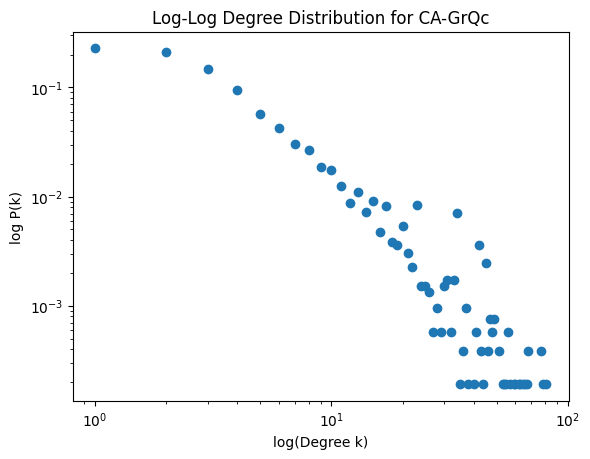

Calculating best minimal value for power law fit


Fitting xmin: 100%|███████████████████████████████████████████████████████████████████| 63/63 [00:00<00:00, 828.93it/s]

alpha (power law exponent): 2.9876
k_min (minimum value of k before power law kicks in): 30



C:\Users\matta\anaconda3\Lib\site-packages\powerlaw\distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,
C:\Users\matta\anaconda3\Lib\site-packages\powerlaw\distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


R>0 indicates power law is more likely. p < 0.05 represents statistical significance.

Power law vs exponential: R=-5.326, p=0.000
Power law vs lognormal: R=-8.337, p=0.013
Power law vs truncated_power_law: R=-5.326, p=0.001
Power law vs stretched_exponential: R=-9.392, p=0.007
Power law vs lognormal_positive: R=-8.337, p=0.013


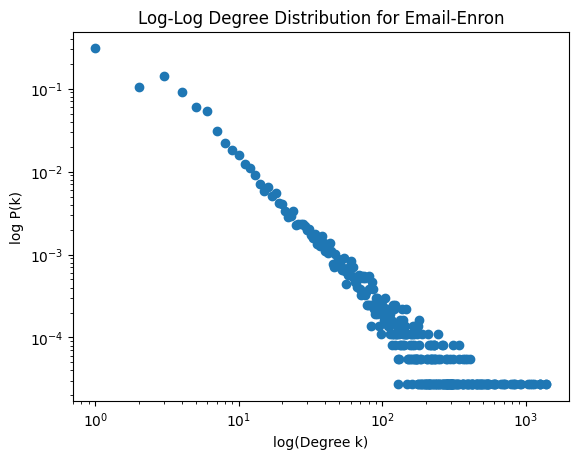

Calculating best minimal value for power law fit


Fitting xmin: 100%|████████████████████████████████████████████████████████████████| 332/332 [00:00<00:00, 1502.27it/s]
C:\Users\matta\anaconda3\Lib\site-packages\powerlaw\distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


alpha (power law exponent): 2.8848
k_min (minimum value of k before power law kicks in): 253


C:\Users\matta\anaconda3\Lib\site-packages\powerlaw\distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


R>0 indicates power law is more likely. p < 0.05 represents statistical significance.

Power law vs exponential: R=0.483, p=0.882
Power law vs lognormal: R=-1.845, p=0.179
Power law vs truncated_power_law: R=-2.336, p=0.031
Power law vs stretched_exponential: R=-2.079, p=0.157
Power law vs lognormal_positive: R=-1.845, p=0.179


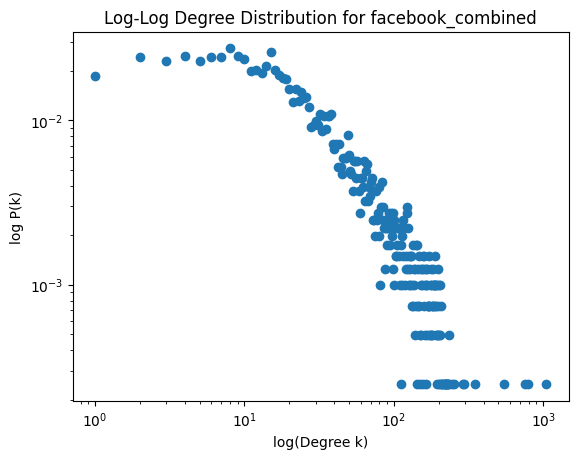

Calculating best minimal value for power law fit


Fitting xmin: 100%|█████████████████████████████████████████████████████████████████| 225/225 [00:00<00:00, 781.25it/s]
C:\Users\matta\anaconda3\Lib\site-packages\powerlaw\distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,


alpha (power law exponent): 2.9923
k_min (minimum value of k before power law kicks in): 105
R>0 indicates power law is more likely. p < 0.05 represents statistical significance.

Power law vs exponential: R=-2.655, p=0.684
Power law vs lognormal: R=-7.589, p=0.149
Power law vs truncated_power_law: R=-3.856, p=0.005
Power law vs stretched_exponential: R=-4.916, p=0.118
Power law vs lognormal_positive: R=-7.589, p=0.149


C:\Users\matta\anaconda3\Lib\site-packages\powerlaw\distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


In [3]:
graph_analyzer = DegreeAnalysis(Path('models'))
graph_analyzer.run_analysis(loglog=True)